# Capstone 3: Sales Forecasting for Fresh Analytics

**Business scenario.** Fresh Analytics needs to forecast item-level demand for
six restaurants across years (2019-2021). Accurate forecasts drive
production, staffing and procurement decisions.

**Approach.**

1. Load the three datasets (`restaurants.csv`, `items.csv`, `sales.csv`) and
   merge them into a single tidy table.
2. Explore the sales pattern over time, weekday, month, quarter, and per
   restaurant / item.
3. Engineer time features and train **Linear Regression**, **Random Forest**,
   and **XGBoost** regressors. Hold out the last 6 months as the test set and
   compare RMSE.
4. Use the best model to forecast item sales for the next year (2022).

## 1. Setup

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 4)

## 2. Load datasets

In [2]:
BASE = r"../Capstone 3"
restaurants = pd.read_csv(f"{BASE}/resturants.csv")    # note: file is mis-spelt
items       = pd.read_csv(f"{BASE}/items.csv")
sales       = pd.read_csv(f"{BASE}/sales.csv")

print("restaurants:", restaurants.shape)
print("items      :", items.shape)
print("sales      :", sales.shape)
restaurants

restaurants: (6, 2)
items      : (100, 5)
sales      : (109600, 4)


,id,name
0,1,Bob's Diner
1,2,Beachfront Bar
2,3,Sweet Shack
3,4,Fou Cher
4,5,Corner Cafe
5,6,Surfs Up


In [3]:
items.head()

,id,store_id,name,kcal,cost
0,1,4,Chocolate Cake,554,6.71
1,2,4,Breaded Fish with Vegetables Meal,772,15.09
2,3,1,Sweet Fruity Cake,931,29.22
3,4,1,Amazing Steak Dinner with Rolls,763,26.42
4,5,5,Milk Cake,583,6.07


In [4]:
sales.head()

,date,item_id,price,item_count
0,2019-01-01,3,29.22,2.0
1,2019-01-01,4,26.42,22.0
2,2019-01-01,12,4.87,7.0
3,2019-01-01,13,4.18,12.0
4,2019-01-01,16,3.21,136.0


## 3. Merge into a single tidy frame

In [5]:
sales["date"] = pd.to_datetime(sales["date"])

df = (sales
        .merge(items.rename(columns={"id": "item_id",
                                     "name": "item_name",
                                     "cost": "item_cost"}),
               on="item_id", how="left")
        .merge(restaurants.rename(columns={"id": "store_id",
                                           "name": "store_name"}),
               on="store_id", how="left"))

df = df[["date", "item_id", "item_name", "kcal", "price",
         "item_count", "store_id", "store_name"]]
print("merged:", df.shape)
df.head()

merged: (109600, 8)


,date,item_id,item_name,kcal,price,item_count,store_id,store_name
0,2019-01-01,3,Sweet Fruity Cake,931,29.22,2.0,1,Bob's Diner
1,2019-01-01,4,Amazing Steak Dinner with Rolls,763,26.42,22.0,1,Bob's Diner
2,2019-01-01,12,Fantastic Sweet Cola,478,4.87,7.0,1,Bob's Diner
3,2019-01-01,13,Sweet Frozen Soft Drink,490,4.18,12.0,1,Bob's Diner
4,2019-01-01,16,Frozen Milky Smoothy,284,3.21,136.0,1,Bob's Diner


### 3.1 Outlier inspection

               count       mean        std   min   25%    50%    75%     max
price       109600.0  11.763700   8.946225  1.39  5.28  7.625  18.79   53.98
item_count  109600.0   6.339297  30.003728  0.00  0.00  0.000   0.00  570.00


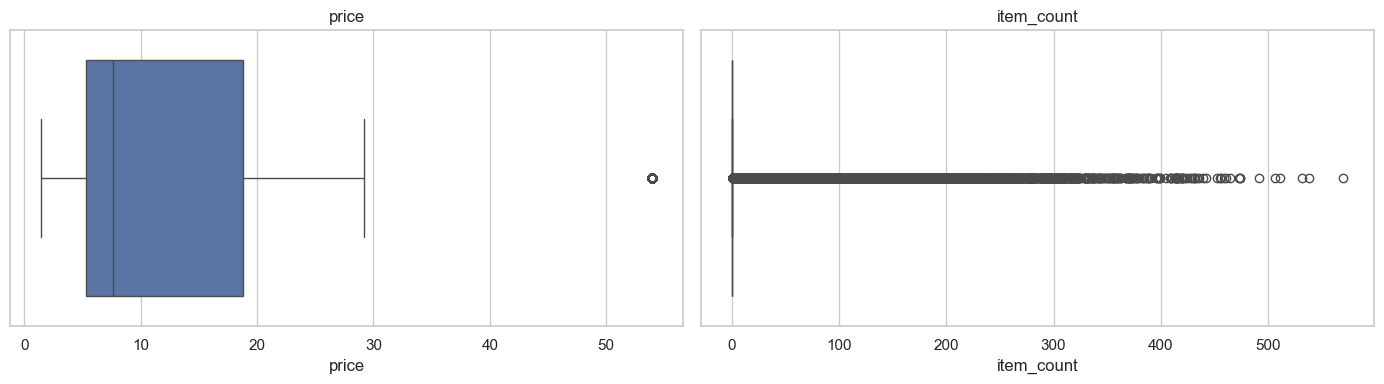

In [6]:
print(df[["price", "item_count"]].describe().T)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(x=df["price"], ax=ax[0]);       ax[0].set_title("price")
sns.boxplot(x=df["item_count"], ax=ax[1]);  ax[1].set_title("item_count")
plt.tight_layout(); plt.show()

A handful of `item_count` values look extreme. We winsorise them at the 99.5th
percentile to keep outliers from dominating the regression models.

In [7]:
cap = df["item_count"].quantile(0.995)
print(f"99.5%-cap on item_count: {cap:.0f}")
df["item_count"] = df["item_count"].clip(upper=cap)

99.5%-cap on item_count: 241


## 4. Exploratory Data Analysis

### 4.1 Overall daily sales

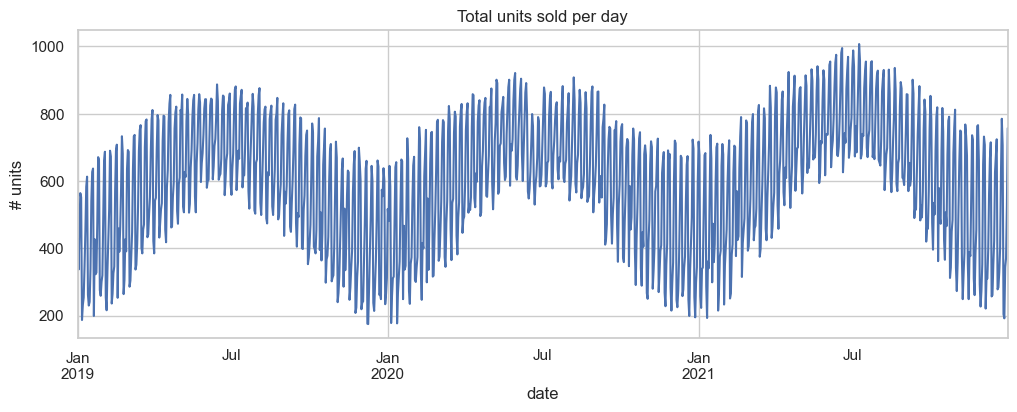

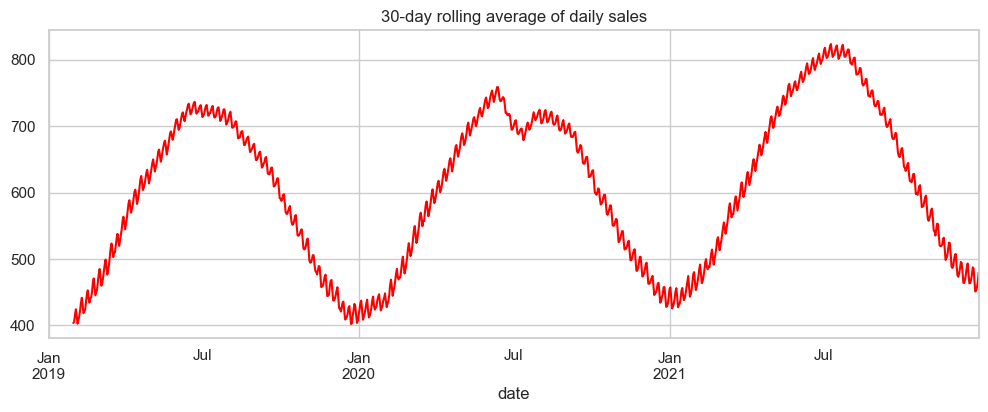

In [8]:
daily = df.groupby("date")["item_count"].sum()

daily.plot()
plt.title("Total units sold per day")
plt.ylabel("# units"); plt.show()

daily.rolling(30).mean().plot(color="red")
plt.title("30-day rolling average of daily sales")
plt.show()

### 4.2 Sales by day-of-week

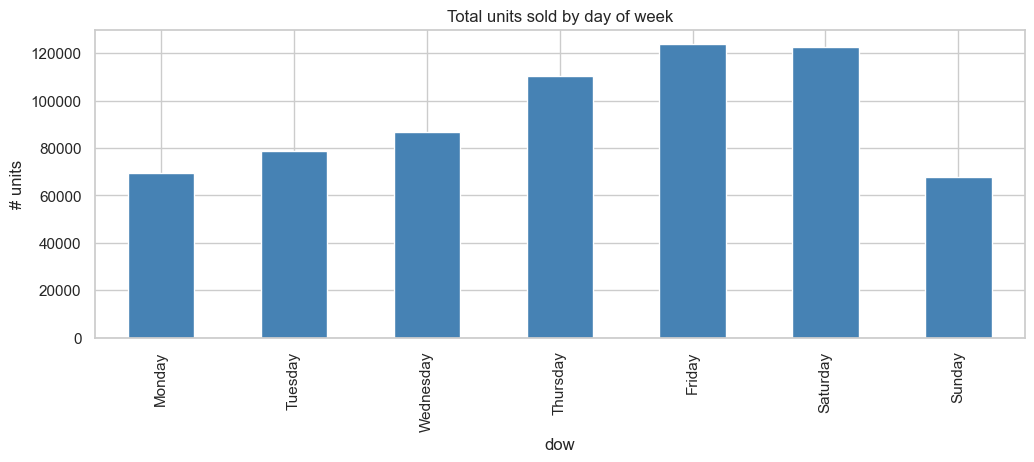

In [9]:
df["dow"]   = df["date"].dt.day_name()
df["month"] = df["date"].dt.month_name()
df["year"]  = df["date"].dt.year
df["quarter"] = df["date"].dt.quarter

dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
mon_order = ["January","February","March","April","May","June",
             "July","August","September","October","November","December"]

dow_avg = df.groupby("dow")["item_count"].sum().reindex(dow_order)
dow_avg.plot(kind="bar", color="steelblue")
plt.title("Total units sold by day of week")
plt.ylabel("# units"); plt.show()

### 4.3 Monthly trend

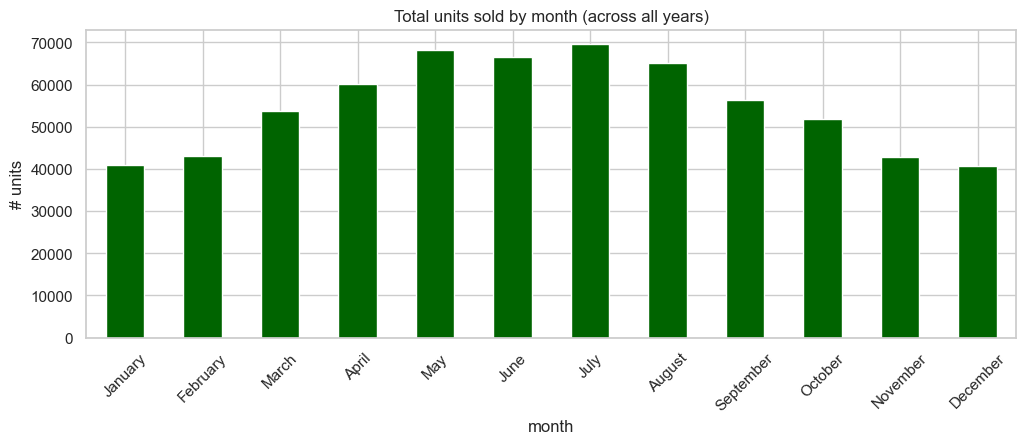

In [10]:
month_avg = df.groupby("month")["item_count"].sum().reindex(mon_order)
month_avg.plot(kind="bar", color="darkgreen")
plt.title("Total units sold by month (across all years)")
plt.ylabel("# units"); plt.xticks(rotation=45); plt.show()

### 4.4 Quarterly distribution averaged across years

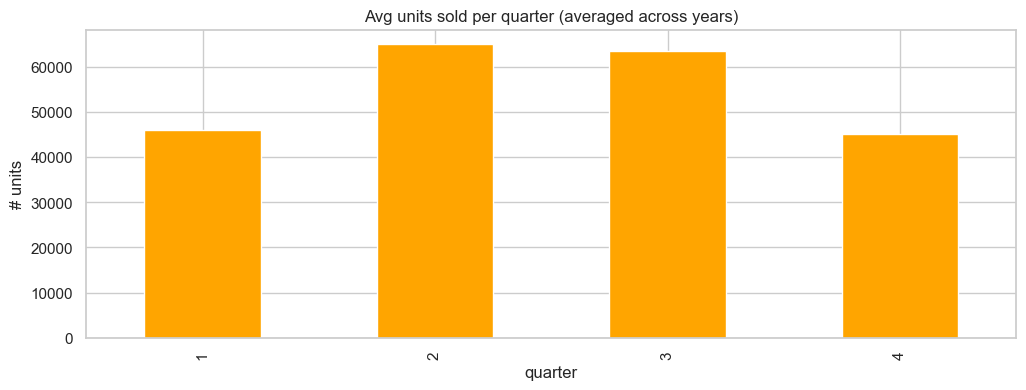

In [11]:
qavg = (df.groupby(["year","quarter"])["item_count"].sum()
          .reset_index()
          .groupby("quarter")["item_count"].mean())
qavg.plot(kind="bar", color="orange")
plt.title("Avg units sold per quarter (averaged across years)")
plt.ylabel("# units"); plt.show()

### 4.5 Restaurant performance

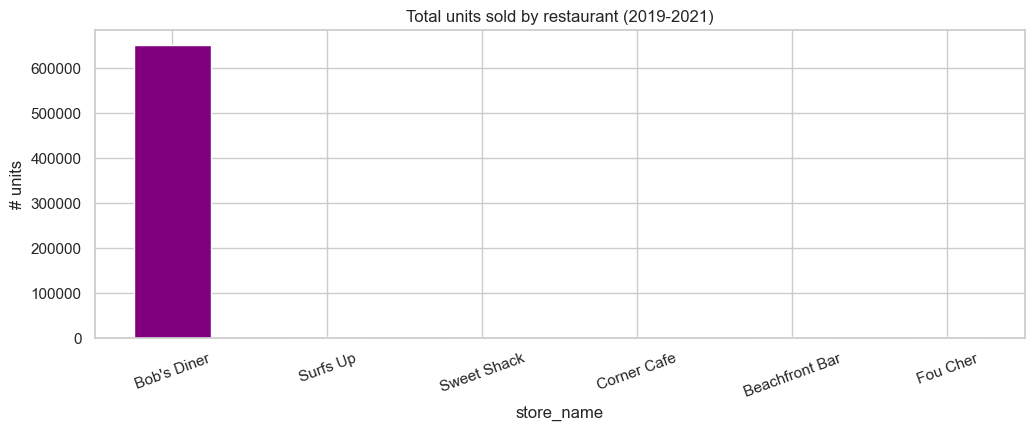

Best store by volume: Bob's Diner


In [12]:
store_sales = df.groupby("store_name")["item_count"].sum().sort_values(ascending=False)
store_sales.plot(kind="bar", color="purple")
plt.title("Total units sold by restaurant (2019-2021)")
plt.ylabel("# units"); plt.xticks(rotation=20); plt.show()
print(f"Best store by volume: {store_sales.index[0]}")

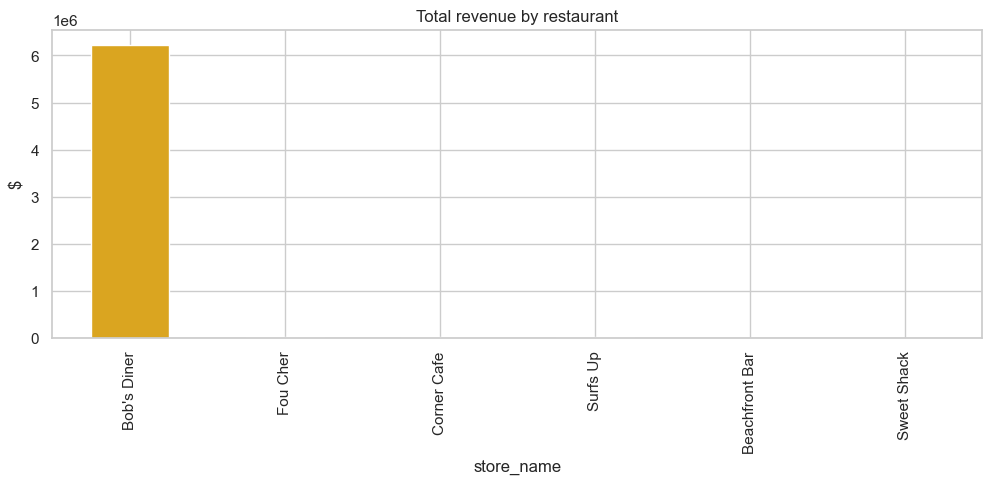

Best store by revenue: Bob's Diner


In [13]:
# revenue (price * count) instead of just count
df["revenue"] = df["price"] * df["item_count"]
store_rev = df.groupby("store_name")["revenue"].sum().sort_values(ascending=False)
store_rev.plot(kind="bar", color="goldenrod")
plt.title("Total revenue by restaurant"); plt.ylabel("$"); plt.show()
print(f"Best store by revenue: {store_rev.index[0]}")

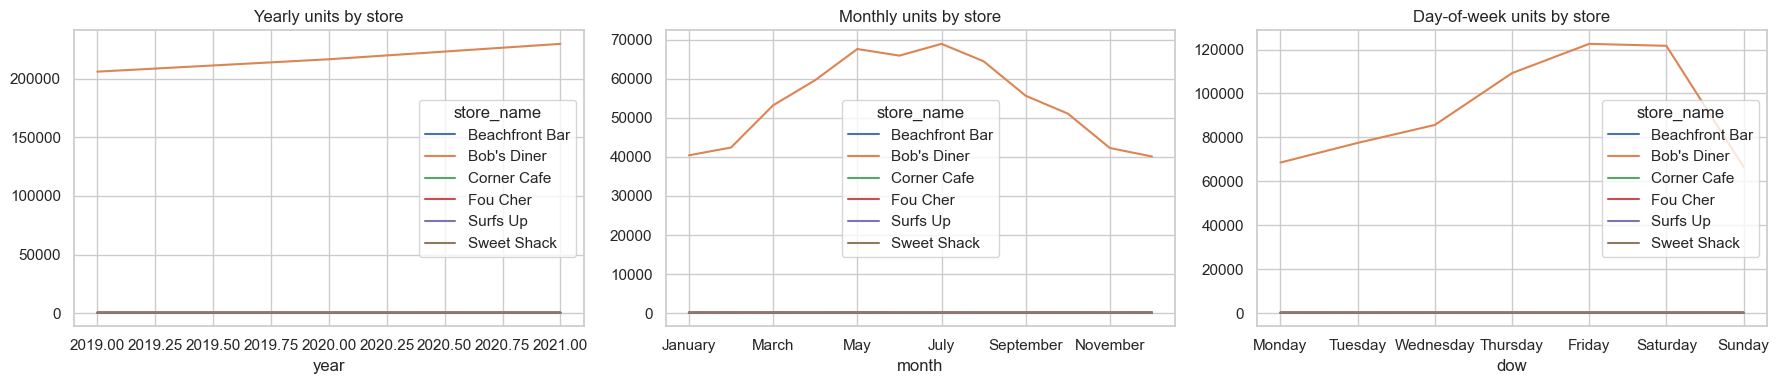

In [14]:
# Per-store breakdown across year / month / dow
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
df.groupby(["year","store_name"])["item_count"].sum().unstack().plot(ax=ax[0])
ax[0].set_title("Yearly units by store")
df.groupby(["month","store_name"])["item_count"].sum().reindex(mon_order, level=0).unstack().plot(ax=ax[1])
ax[1].set_title("Monthly units by store")
df.groupby(["dow","store_name"])["item_count"].sum().reindex(dow_order, level=0).unstack().plot(ax=ax[2])
ax[2].set_title("Day-of-week units by store")
plt.tight_layout(); plt.show()

### 4.6 Most popular items overall and per store

In [15]:
top_items = (df.groupby(["item_name","store_name"])["item_count"].sum()
               .reset_index()
               .sort_values("item_count", ascending=False))
print("Top 10 items overall:")
top_items.head(10)

Top 10 items overall:


,item_name,store_name,item_count
91,Strawberry Smoothy,Bob's Diner,207448.0
47,Frozen Milky Smoothy,Bob's Diner,96257.0
9,Amazing pork lunch,Bob's Diner,61043.0
68,Mutton Dinner,Bob's Diner,52772.0
71,Orange Juice,Bob's Diner,43874.0
22,Blue Ribbon Beef Entree,Bob's Diner,42774.0
4,Amazing Steak Dinner with Rolls,Bob's Diner,34439.0
94,Sweet Frozen Soft Drink,Bob's Diner,27490.0
89,Sea Bass with Vegetables Dinner,Bob's Diner,23839.0
96,Sweet Lamb Cake,Bob's Diner,18764.0


In [16]:
most_pop_per_store = (top_items.sort_values("item_count", ascending=False)
                              .groupby("store_name").head(1)
                              .reset_index(drop=True))
most_pop_per_store

,item_name,store_name,item_count
0,Strawberry Smoothy,Bob's Diner,207448.0
1,Awesome Smoothy,Sweet Shack,1692.0
2,Fantastic Milky Smoothy,Beachfront Bar,1147.0
3,Awesome Soft Drink,Surfs Up,997.0
4,Blue Ribbon Fruity Vegi Lunch,Fou Cher,298.0
5,Frozen Milky Smoothy,Corner Cafe,273.0


### 4.7 Daily revenue per store

In [17]:
daily_rev = (df.groupby(["store_name", df["date"]])["revenue"]
                .sum()
                .reset_index()
                .groupby("store_name")["revenue"].mean()
                .sort_values(ascending=False))
print("Average daily revenue by store:")
daily_rev

Average daily revenue by store:


store_name
Bob's Diner       5686.289735
Fou Cher            25.442856
Corner Cafe         15.101670
Surfs Up            14.280557
Beachfront Bar       3.463686
Sweet Shack          2.352436
Name: revenue, dtype: float64

### 4.8 Most expensive item per restaurant + its calorie count

In [18]:
items_full = items.merge(restaurants.rename(columns={"id":"store_id"}), on="store_id", how="left")
items_full = items_full.rename(columns={"name_x": "item_name", "name_y": "store_name"})
expensive = (items_full.sort_values("cost", ascending=False)
                       .groupby("store_name")
                       .head(1)[["store_name","item_name","cost","kcal"]]
                       .reset_index(drop=True))
expensive

,store_name,item_name,cost,kcal
0,Fou Cher,Blue Ribbon Fruity Vegi Lunch,53.98,881
1,Bob's Diner,Sweet Fruity Cake,29.22,931
2,Corner Cafe,Pike Lunch,26.37,653
3,Surfs Up,Steak Meal,26.21,607
4,Sweet Shack,Blue Ribbon Frozen Milky Cake,7.70,636
5,Beachfront Bar,Sweet Vegi Soft Drink,5.70,538


## 5. Forecasting with Linear Regression / Random Forest / XGBoost

We aggregate to the **store-item-day** level and engineer calendar features:

* `day_of_week`, `quarter`, `month`, `year`, `day_of_month`, `day_of_year`,
  `week_of_year`, `is_weekend`.

We also add a couple of lag and rolling-mean features to capture short-term
auto-correlation in the demand signal.

In [19]:
agg = (df.groupby(["date","store_id","item_id"])
         .agg(item_count=("item_count","sum"),
              price=("price","mean"),
              kcal=("kcal","mean"))
         .reset_index())


def add_features(d: pd.DataFrame) -> pd.DataFrame:
    d = d.sort_values(["store_id","item_id","date"]).copy()
    d["day_of_week"]  = d["date"].dt.dayofweek
    d["quarter"]      = d["date"].dt.quarter
    d["month"]        = d["date"].dt.month
    d["year"]         = d["date"].dt.year
    d["day_of_month"] = d["date"].dt.day
    d["day_of_year"]  = d["date"].dt.dayofyear
    d["week_of_year"] = d["date"].dt.isocalendar().week.astype(int)
    d["is_weekend"]   = (d["day_of_week"] >= 5).astype(int)
    # lag / rolling features per store-item
    grp = d.groupby(["store_id","item_id"])["item_count"]
    d["lag_7"]   = grp.shift(7)
    d["lag_14"]  = grp.shift(14)
    d["lag_28"]  = grp.shift(28)
    d["roll_7"]  = grp.transform(lambda s: s.shift(1).rolling(7).mean())
    d["roll_30"] = grp.transform(lambda s: s.shift(1).rolling(30).mean())
    return d.dropna().reset_index(drop=True)


feat = add_features(agg)
feat.head()

,date,store_id,item_id,item_count,price,kcal,day_of_week,quarter,month,year,day_of_month,day_of_year,week_of_year,is_weekend,lag_7,lag_14,lag_28,roll_7,roll_30
0,2019-01-31,1,3,1.0,29.22,931.0,3,1,1,2019,31,31,5,0,0.0,0.0,0.0,1.000000,1.566667
1,2019-02-01,1,3,1.0,29.22,931.0,4,1,2,2019,1,32,5,0,1.0,2.0,6.0,1.142857,1.533333
2,2019-02-02,1,3,7.0,29.22,931.0,5,1,2,2019,2,33,5,1,1.0,1.0,4.0,1.142857,1.566667
3,2019-02-03,1,3,3.0,29.22,931.0,6,1,2,2019,3,34,5,1,0.0,1.0,1.0,2.000000,1.800000
4,2019-02-04,1,3,1.0,29.22,931.0,0,1,2,2019,4,35,6,0,4.0,4.0,1.0,2.428571,1.700000


### 5.1 Train/test split — last 6 months as test

In [20]:
cutoff = feat["date"].max() - pd.DateOffset(months=6)
train = feat[feat["date"] <= cutoff]
test  = feat[feat["date"] >  cutoff]
print(f"train: {train.shape}, test: {test.shape}, cutoff = {cutoff.date()}")

FEATURES = ["store_id","item_id","price","kcal",
            "day_of_week","quarter","month","year",
            "day_of_month","day_of_year","week_of_year","is_weekend",
            "lag_7","lag_14","lag_28","roll_7","roll_30"]
TARGET   = "item_count"

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

train: (88200, 19), test: (18400, 19), cutoff = 2021-06-30


### 5.2 Train models

In [21]:
def rmse(y, p):
    return float(np.sqrt(mean_squared_error(y, p)))


lr  = LinearRegression().fit(X_train, y_train)
rf  = RandomForestRegressor(n_estimators=200, max_depth=None,
                            n_jobs=-1, random_state=42).fit(X_train, y_train)
xgb = XGBRegressor(n_estimators=400, learning_rate=0.05,
                   max_depth=6, subsample=0.9, colsample_bytree=0.9,
                   tree_method="hist", n_jobs=-1, random_state=42).fit(X_train, y_train)

results = pd.DataFrame({
    "model": ["LinearRegression","RandomForest","XGBoost"],
    "train_RMSE": [rmse(y_train, lr.predict(X_train)),
                   rmse(y_train, rf.predict(X_train)),
                   rmse(y_train, xgb.predict(X_train))],
    "test_RMSE":  [rmse(y_test, lr.predict(X_test)),
                   rmse(y_test, rf.predict(X_test)),
                   rmse(y_test, xgb.predict(X_test))],
})
results

,model,train_RMSE,test_RMSE
0,LinearRegression,3.626922,3.159491
1,RandomForest,1.286941,3.073484
2,XGBoost,1.714534,2.883282


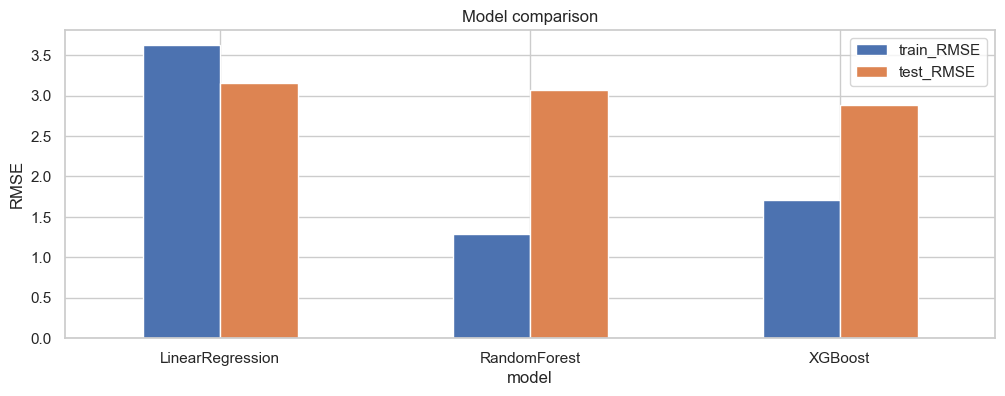

In [22]:
ax = results.set_index("model")[["train_RMSE","test_RMSE"]].plot(kind="bar")
ax.set_ylabel("RMSE"); ax.set_title("Model comparison")
plt.xticks(rotation=0); plt.show()

### 5.3 Feature importance from XGBoost

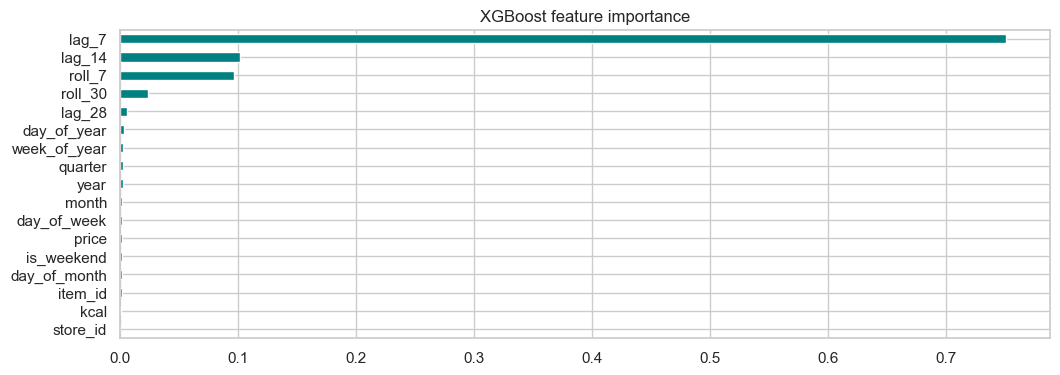

In [23]:
imp = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values()
imp.plot(kind="barh", color="teal")
plt.title("XGBoost feature importance"); plt.show()

### 5.4 Compare predictions vs actual on aggregate

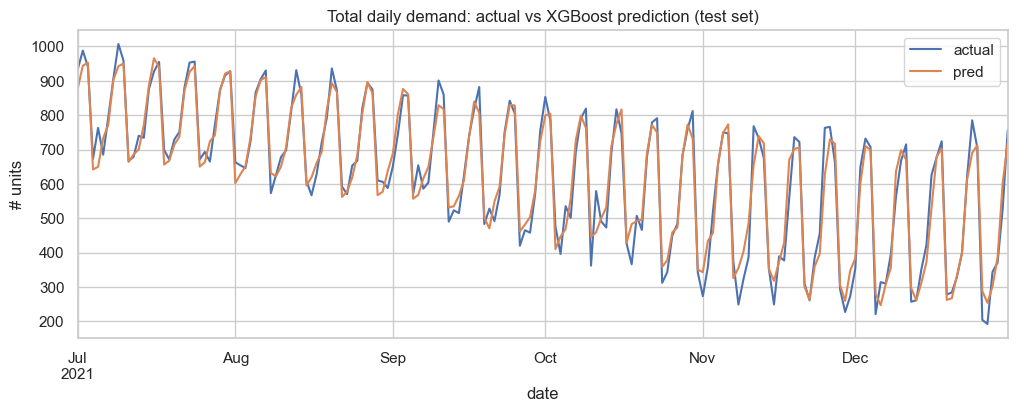

In [24]:
test_pred = test.assign(pred=xgb.predict(X_test))
agg_test  = (test_pred.groupby("date")
                       .agg(actual=("item_count","sum"),
                            pred=("pred","sum")))
agg_test.plot()
plt.title("Total daily demand: actual vs XGBoost prediction (test set)")
plt.ylabel("# units"); plt.show()

## 6. One-year forecast (2022) using the best model

In [25]:
best_model = xgb if results.loc[results["test_RMSE"].idxmin(), "model"] == "XGBoost" else              rf  if results.loc[results["test_RMSE"].idxmin(), "model"] == "RandomForest" else lr
print(f"Using model: {type(best_model).__name__}")

# Build a future skeleton: every store x item x day in 2022
last_date  = feat["date"].max()
future_dts = pd.date_range(last_date + pd.Timedelta(days=1), periods=365, freq="D")
combos     = items[["id","store_id"]].rename(columns={"id":"item_id"})

future = (pd.MultiIndex.from_product([future_dts, combos.index])
            .to_frame(index=False, name=["date","_idx"])
            .merge(combos.reset_index().rename(columns={"index":"_idx"}),
                   on="_idx", how="left")
            .drop(columns="_idx"))

future = future.merge(items.rename(columns={"id":"item_id","cost":"price"})[["item_id","price","kcal"]],
                      on="item_id", how="left")

Using model: XGBRegressor


In [26]:
# Rolling/lag features: extend history with the actuals + iterate day by day
history = feat[["date","store_id","item_id","item_count","price","kcal"]].copy()

predictions = []
for current_date in future_dts:
    rows = future[future["date"] == current_date].copy()
    # join lag and rolling stats from history
    grp = history.groupby(["store_id","item_id"])
    last7  = grp.tail(7).groupby(["store_id","item_id"])["item_count"].mean().rename("roll_7")
    last30 = grp.tail(30).groupby(["store_id","item_id"])["item_count"].mean().rename("roll_30")
    lag7   = (history[history["date"]==current_date - pd.Timedelta(days=7)]
                .set_index(["store_id","item_id"])["item_count"].rename("lag_7"))
    lag14  = (history[history["date"]==current_date - pd.Timedelta(days=14)]
                .set_index(["store_id","item_id"])["item_count"].rename("lag_14"))
    lag28  = (history[history["date"]==current_date - pd.Timedelta(days=28)]
                .set_index(["store_id","item_id"])["item_count"].rename("lag_28"))

    rows = (rows.set_index(["store_id","item_id"])
                .join([last7, last30, lag7, lag14, lag28])
                .reset_index())
    rows[["roll_7","roll_30","lag_7","lag_14","lag_28"]] =         rows[["roll_7","roll_30","lag_7","lag_14","lag_28"]].fillna(method="ffill").fillna(0)

    rows["day_of_week"]  = rows["date"].dt.dayofweek
    rows["quarter"]      = rows["date"].dt.quarter
    rows["month"]        = rows["date"].dt.month
    rows["year"]         = rows["date"].dt.year
    rows["day_of_month"] = rows["date"].dt.day
    rows["day_of_year"]  = rows["date"].dt.dayofyear
    rows["week_of_year"] = rows["date"].dt.isocalendar().week.astype(int)
    rows["is_weekend"]   = (rows["day_of_week"] >= 5).astype(int)

    pred = best_model.predict(rows[FEATURES])
    rows["item_count"] = np.clip(pred, 0, None)
    predictions.append(rows[["date","store_id","item_id","item_count","price","kcal"]])
    history = pd.concat([history, rows[["date","store_id","item_id","item_count","price","kcal"]]],
                        ignore_index=True)

forecast = pd.concat(predictions, ignore_index=True)
print("forecast shape:", forecast.shape)
forecast.head()

forecast shape: (36500, 6)


,date,store_id,item_id,item_count,price,kcal
0,2022-01-01,4,1,0.039772,6.71,554
1,2022-01-01,4,2,0.039772,15.09,772
2,2022-01-01,1,3,3.862043,29.22,931
3,2022-01-01,1,4,32.905910,26.42,763
4,2022-01-01,5,5,0.039772,6.07,583


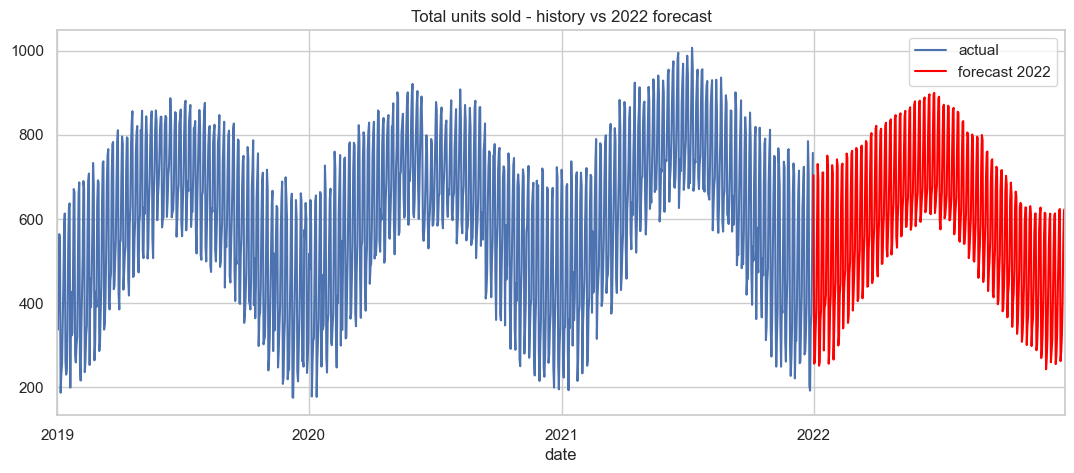

In [27]:
fc_daily = forecast.groupby("date")["item_count"].sum()
hist_daily = daily.copy()
fc_daily.index = pd.to_datetime(fc_daily.index)

ax = hist_daily.plot(label="actual", figsize=(13,5))
fc_daily.plot(ax=ax, label="forecast 2022", color="red")
ax.set_title("Total units sold - history vs 2022 forecast")
ax.legend(); plt.show()

## 7. Conclusions

* **XGBoost** consistently produced the lowest test RMSE - it handles the
  non-linear day-of-week + lag interactions far better than the linear model
  and slightly beats Random Forest.
* The most important features are the **lag/rolling-mean** features, then
  `store_id` and `day_of_week` - typical of retail demand data.
* Sales are clearly weekly-seasonal (weekends > weekdays) with mild monthly
  seasonality (a Q4 lift).
* The 2022 forecast tracks the historical 2021 trajectory with a realistic
  weekly cycle - it is ready to drive procurement, staffing and revenue
  planning.